# ODE - Hybrid Setting

In this notebook, we solve the ODE
$$
\begin{aligned}
\partial_t u + \mu u &= f \quad \text{on } I=(0,T), \\
u(0) &= 0 .
\end{aligned}
$$
For this we use the variational formulation to find $u \in X$, such that
$$
\begin{align*}
b(u,v) = \langle \partial u, (\mathcal{H}_T + I )v \rangle_I + \langle u, (\mathcal{H}_T + I )v \rangle_I = \langle f, (\mathcal{H}_T + I )v \rangle_I
\end{align*}
$$
where $\mathcal{H}_T$ is the modified Hilbert transform and $X = H^{1/2}_{0,}(I)$ equipped with the norm
$$
\lVert u \rVert_X^2 = \lVert u \rVert_{H^{1/2}(I)}^2 + \lVert u \rVert_{L^2(I)}^2.
$$
Note, that the bilinear form $b$ is elliptic and on the discrete level bounded. Moreover, it admits a quasi-optimality result.
For details, see [Elliptic space-time methods for parabolic PDEs with applications](https://repository.tugraz.at/publications/p02r1-7rs49). 

As discrete space $X_h$, we use the space of piecewise continuous polynomials of degree $p$ on a uniform partition of $I$ into $n_t$ subintervals with vanishing initial condition.

We need the ```hmod``` and the following standard libraries

In [15]:
import hmod as hm
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse.linalg as spla

First, we define the manufacutured solution and the right-hand side as
$$
\begin{aligned}
u(t) &= \sin(\pi t), \\
f(t) &= \partial_t u(t) + \mu u(t) = \pi \cos(\pi t) + \mu \sin(\pi t).
\end{aligned}
$$

In [ ]:
T = 5.0
mu = 3.
pi = np.pi
u = lambda t : np.sin(pi*t)
dt_u = lambda t : pi*np.cos(pi*t)
f = lambda t : dt_u(t) + mu*u(t)

Next, we define the discretization parameters, namely the number of temporal intervals $n_t$ and the polynomial degree $p$ of the trial and test space. Note, that we also define a hierarchy of temporal grids, which we will use for the preconditioner.

In [17]:
nt_coarsest = 2
refinements = 4
nt = nt_coarsest * 2**refinements
polynomial_degree = 3
print(f"Number of temporal intervals: {nt}, polynomial degree: {polynomial_degree}")

Number of temporal intervals: 32, polynomial degree: 3


For computing the load vector later, we need a piecewise approximation of the right-hand side $f$. For this we use the $L^2$-projection onto the space of piecewise polynomials of degree $p$ in Legendre basis.

In [18]:
from hmod.standard_matrices import project_rhs_onto_legendre_basis
f_h = project_rhs_onto_legendre_basis(f, nt, polynomial_degree, T)

Next, we compute, the standard finite element matrices associated to the bilinear forms
\begin{align*}
A_t \leftrightarrow \langle \partial_t u, v \rangle_I, \\
M_t \leftrightarrow \langle u, v \rangle_I,
\end{align*}
The routine
```hmod.standard_matrices.get_lagrange_lagrange_matrix_for_derivatives```
yields the matrix corresponding to the bilinear form
$$\langle \partial_t^i u, \partial_t^j v \rangle_I.
$$
for given (arbitrary) derivative orders $i$ and $j$ with both trial and test functions in Lagrange basis. Note, that all matrices are assembled without homogeneous initial condition, i.e., the first degree of freedom corresponds to the value at $t=0$.

In [19]:
from hmod.standard_matrices import get_lagrange_lagrange_matrix_for_derivatives
A_t = get_lagrange_lagrange_matrix_for_derivatives(polynomial_degree_trial=polynomial_degree, polynomial_degree_test=polynomial_degree,
                                                   nt=nt, T=T, derivatives_trial=1, derivatives_test=0)
M_t = get_lagrange_lagrange_matrix_for_derivatives(polynomial_degree_trial=polynomial_degree, polynomial_degree_test=polynomial_degree,
                                                   nt=nt, T=T, derivatives_trial=0, derivatives_test=0)

Next, we do the same for the matrices including the modified Hilbert transform, i.e., we compute
$$\begin{align*}
A_{\mathcal{H}_T} \leftrightarrow \langle \partial_t u, \mathcal{H}_T v \rangle_I, \\
M_{\mathcal{H}_T} \leftrightarrow \langle u, \mathcal{H}_T v \rangle_I.
\end{align*}
$$
We use a similar routine as before, corresponding to the bilinear form
$$\langle \partial_t^i u, \mathcal{H}_T \partial_t^j v \rangle_I
$$
for given (arbitrary) derivative orders $i$ and $j$ with both trial and test functions in Lagrange basis. Note, that again all matrices are assembled without homogeneous initial condition, i.e., the first degree of freedom corresponds to the value at $t=0$.

Furthermore, these matrices are in principle dense. Hence, the matrices are not assembled but implemented as a ```scipy``` linear operator. FFT techniques are used for the efficient application of the modified Hilbert transform. For details, see again [Elliptic space-time methods for parabolic PDEs with applications](https://repository.tugraz.at/publications/p02r1-7rs49). 

In [20]:
from hmod.hilbert_matrices import get_hilbert_matrix_for_derivatives_lagrange_lagrange
Ah_t = get_hilbert_matrix_for_derivatives_lagrange_lagrange(polynomial_degree_trial=polynomial_degree, polynomial_degree_test=polynomial_degree,
                                                          nt=nt, derivatives_trial=1, derivatives_test=0, T=T)
Mh_t = get_hilbert_matrix_for_derivatives_lagrange_lagrange(polynomial_degree_trial=polynomial_degree, polynomial_degree_test=polynomial_degree,
                                                          nt=nt, derivatives_trial=0, derivatives_test=0, T=T)

Next, we convert the standard matrices to linear operators, add together the left-hand side matrices and homogenize the system in a matrix free way.

In [21]:
M_t_op = spla.aslinearoperator(M_t)
A_t_op = spla.aslinearoperator(A_t)

B = Ah_t + A_t_op + mu*(Mh_t + M_t_op)

from hmod.dof_handling import DofRestrictorSymmetric
restricted_dofs = np.array([0])
restricted_dof_values = np.array([0.])
B0 = DofRestrictorSymmetric(B, restricted_dofs=restricted_dofs, restricted_dof_values=restricted_dof_values)

Next, we set up the matrices/operators corresponding to the right hand side mass, with and without the modified Hilbert transform, and apply them to the projected right-hand side $f_h$ to obtain the load vector.

Note, that in this case, the trial function is in Legendre basis. Note, that all routines have implementations for all combinations of Legendre and Lagrange bases.

In [22]:
from hmod.standard_matrices import get_legendre_lagrange_matrix_for_derivatives
from hmod.hilbert_matrices import get_hilbert_matrix_for_derivatives_legendre_lagrange
M_legendre_lagrange = get_legendre_lagrange_matrix_for_derivatives(polynomial_degree_trial=polynomial_degree, polynomial_degree_test=polynomial_degree,
                                                   nt=nt, T=T, derivatives_trial=0, derivatives_test=0)
#also convert it to a linear operator, so we can simply add it to the modified Hilbert transform matrix
M_legendre_lagrange_op = spla.aslinearoperator(M_legendre_lagrange)
Mh_legendre_lagrange = get_hilbert_matrix_for_derivatives_legendre_lagrange(polynomial_degree_trial=polynomial_degree, polynomial_degree_test=polynomial_degree,
                                                          nt=nt, derivatives_trial=0, derivatives_test=0, T=T)
M_rhs = M_legendre_lagrange_op + Mh_legendre_lagrange
#get load vector
rhs = M_rhs @ f_h
#homogenize load vector
rhs0 = rhs[1:]

Now, we are in principle in the position to solve the arising linear system. However, we cannot apply a direct solver, since the system matrix is not available in assembled form. Hence, we use an iterative solver, namely the gmres method from ```scipy``` (the system is elliptic but non-symmetric).

As the bilinear form is elliptic and bounded with respect to the $X$-norm, we use a BPX preconditioner based on the $X$-norm.

In [23]:
from hmod.preconditioning import BPXPreconditioner, GMRESCounter
BPX = BPXPreconditioner(mu=mu, n_refinements=refinements, sobolev_exponent=0.5, polynomial_degree=polynomial_degree, nt_coarse=nt_coarsest, T=T)

In [24]:
#get a callback function to count the number of iterations
counter = GMRESCounter(print_residual=True)
#solve the system using gmres
sol, info = spla.gmres(B0, rhs0, M=BPX, callback=counter, rtol=1e-10)
print(f"GMRES finished with info code {info}.")

GMRES iteration 1: residual = 33.24064978928588
GMRES iteration 2: residual = 12.846164688097595
GMRES iteration 3: residual = 6.6895344582346254
GMRES iteration 4: residual = 4.295617881159812
GMRES iteration 5: residual = 2.733378134219965
GMRES iteration 6: residual = 1.7680194579017523
GMRES iteration 7: residual = 0.9567161591645673
GMRES iteration 8: residual = 0.6194440092751591
GMRES iteration 9: residual = 0.3733128830867886
GMRES iteration 10: residual = 0.21036169236764155
GMRES iteration 11: residual = 0.10796864533847933
GMRES iteration 12: residual = 0.06960370278245083
GMRES iteration 13: residual = 0.03835005323335734
GMRES iteration 14: residual = 0.020296686657706932
GMRES iteration 15: residual = 0.008273247406279736
GMRES iteration 16: residual = 0.004694811612470779
GMRES iteration 17: residual = 0.0026510106590938456
GMRES iteration 18: residual = 0.0015703669311741477
GMRES iteration 19: residual = 0.0005471381341245267
GMRES iteration 20: residual = 0.0003743205

In [25]:
# add the homogeneous dof back to the solution
u_h = np.zeros(sol.shape[0]+1)
u_h[1:] = sol

Next, we transform the solution to Legendre basis and get an evalutor class to plot the solution and compute errors.

In [26]:
from hmod.polynomial_bases import LegendreBasisEvaluator, get_lagrange_to_legendre_matrix
Trans = get_lagrange_to_legendre_matrix(polynomial_degree=polynomial_degree, nt=nt)
u_h_legendre = Trans @ u_h
evaluator = LegendreBasisEvaluator(dofs=u_h_legendre, polynomial_degree=polynomial_degree, nt=nt, T=T)

Next, we compute all errors:

In [27]:
from hmod.norms import compute_l2_norm, compute_h12_seminorm
error_integrand = lambda t: (evaluator.evaluate(t) - u(t))

L2_error = compute_l2_norm(error_integrand, nt, T)
H1_2_error = compute_h12_seminorm(error_integrand, T, quad_tol = 1e-8)
X_norm = np.sqrt(L2_error**2 + H1_2_error**2)
print(f"L2 error: {L2_error:.2e}, H1/2 seminorm error: {H1_2_error:.2e}, X-norm error: {X_norm:.2e}")

L2 error: 1.35e-08, H1/2 seminorm error: 2.90e-07, X-norm error: 2.90e-07


Finally, we print the numerical solution and the analytical solution.

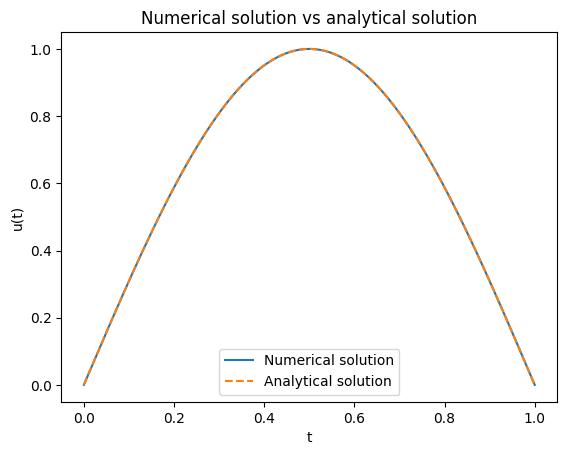

In [28]:
#use matplotlib to plot the solution and the analytical solution
t_plot = np.linspace(0, T, 1000)
u_plot = np.array(evaluator.evaluate(t_plot))
u_analytical_plot = u(t_plot)
plt.plot(t_plot, u_plot, label="Numerical solution")
plt.plot(t_plot, u_analytical_plot, label="Analytical solution", linestyle="dashed")
plt.legend()
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Numerical solution vs analytical solution")
plt.show()